In [ ]:
#Setup and dependencies

In [3]:
# If running in a fresh environment, install these dependencies.
# You can disable installation in managed environments or bake into Docker.

!pip install gymnasium
!pip install stable-baselines3[extra]
!pip install torch
!pip install fastapi uvicorn
!pip install pydantic
!pip install numpy pandas
!pip install prometheus-client
!pip install tensorboard

In [ ]:
#Custom student simulation environment
#The environment models a student’s latent mastery, engagement, and fatigue; the agent chooses the next content item difficulty and modality to maximize cumulative learning reward.

In [22]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class AdaptiveLearningEnv(gym.Env):
    """
    Custom Environment for Adaptive Learning Pathways
    State: [topic mastery, recent quiz score, engagement level]
    Actions: [recommend next topic, review material, quiz, rest]
    Reward: based on mastery improvement, engagement, and quiz performance
    """
    metadata = {"render.modes": ["human"]}

    def __init__(self):
        super(AdaptiveLearningEnv, self).__init__()
        
        # State space: mastery (0-1), quiz score (0-1), engagement (0-1)
        self.observation_space = spaces.Box(low=0, high=1, shape=(3,), dtype=np.float32)
        
        # Action space: 0=next topic, 1=review, 2=quiz, 3=rest
        self.action_space = spaces.Discrete(4)
        
        # Initialize state
        self.state = np.array([0.2, 0.5, 0.7], dtype=np.float32)  # example starting values
        self.steps = 0
        self.max_steps = 50

    def step(self, action):
        mastery, quiz_score, engagement = self.state
        
        # Transition dynamics (simplified)
        if action == 0:  # next topic
            mastery += np.random.uniform(0.01, 0.05)
            engagement -= 0.05
        elif action == 1:  # review
            mastery += np.random.uniform(0.02, 0.06)
            engagement += 0.02
        elif action == 2:  # quiz
            quiz_score = np.random.uniform(0, 1)
            mastery += 0.1 if quiz_score > 0.7 else -0.05
        elif action == 3:  # rest
            engagement += 0.1
        
        # Clip values to [0,1]
        mastery = np.clip(mastery, 0, 1)
        quiz_score = np.clip(quiz_score, 0, 1)
        engagement = np.clip(engagement, 0, 1)
        
        self.state = np.array([mastery, quiz_score, engagement], dtype=np.float32)
        self.steps += 1
        
        # Reward function
        reward = mastery + (0.5 * engagement) + (0.2 * quiz_score)
        
        # Episode termination
        done = self.steps >= self.max_steps or mastery >= 1.0
        truncated = False
        
        return self.state, reward, done, truncated, {}

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.state = np.array([0.2, 0.5, 0.7], dtype=np.float32)
        self.steps = 0
        return self.state, {}

    def render(self, mode="human"):
        print(f"Step: {self.steps}, State: {self.state}")

In [23]:
#Test the Environment

env = AdaptiveLearningEnv()

obs, _ = env.reset()
for _ in range(10):
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    env.render()
    if done:
        break

Step: 1, State: [0.2 0.5 0.8]
Step: 2, State: [0.2        0.5        0.90000004]
Step: 3, State: [0.22815478 0.5        0.85      ]
Step: 4, State: [0.26590943 0.5        0.87      ]
Step: 5, State: [0.26590943 0.5        0.97      ]
Step: 6, State: [0.21590944 0.3735359  0.97      ]
Step: 7, State: [0.27402323 0.3735359  0.99      ]
Step: 8, State: [0.22402324 0.42667335 0.99      ]
Step: 9, State: [0.17402324 0.6535636  0.99      ]
Step: 10, State: [0.22119617 0.6535636  0.94      ]


In [25]:
  # Train with Stable Baselines3
from stable_baselines3 import DQN

env = AdaptiveLearningEnv()
model = DQN("MlpPolicy", env, verbose=1, learning_rate=0.001, buffer_size=10000)
model.learn(total_timesteps=5000)

# Test trained agent
obs, _ = env.reset()
for _ in range(10):
    action, _states = model.predict(obs)
    obs, reward, done, truncated, info = env.step(action)
    env.render()
    if done:
        break

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 44.5     |
|    ep_rew_mean      | 50.3     |
|    exploration_rate | 0.662    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 147      |
|    time_elapsed     | 1        |
|    total_timesteps  | 178      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.373    |
|    n_updates        | 19       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 41.6     |
|    ep_rew_mean      | 44.8     |
|    exploration_rate | 0.367    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 227      |
|    time_elapsed     | 1        |
|    total_timesteps  | 333      |
| train/              |        

In [26]:
env.close()

In [27]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
import os

In [28]:
# Create log directory
log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)

In [29]:
# Wrap environment with Monitor for logging
env = AdaptiveLearningEnv()
env = Monitor(env, log_dir)

In [30]:
# Define evaluation callback
eval_callback = EvalCallback(env, best_model_save_path="./best_model/",
                             log_path=log_dir, eval_freq=1000,
                             deterministic=True, render=False)


In [31]:
# Train with TensorBoard logging enabled
model = DQN("MlpPolicy", env, verbose=1, tensorboard_log=log_dir,
            learning_rate=0.001, buffer_size=10000)

model.learn(total_timesteps=10000, callback=eval_callback)

Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to ./logs/DQN_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 35       |
|    ep_rew_mean      | 36.9     |
|    exploration_rate | 0.867    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 781      |
|    time_elapsed     | 0        |
|    total_timesteps  | 140      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.498    |
|    n_updates        | 9        |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 38.6     |
|    ep_rew_mean      | 41       |
|    exploration_rate | 0.706    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 647      |
|    time_elapsed     | 0        |
|    total_timesteps  | 309      |
| train/              |          |
|    learning_

In [33]:
from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
import os

# Create log directory
log_dir = "./logs/"
os.makedirs(log_dir, exist_ok=True)

# Wrap environment with Monitor for logging
env = AdaptiveLearningEnv()
env = Monitor(env, log_dir)

# Define evaluation callback
eval_callback = EvalCallback(env, best_model_save_path="./best_model/",
                             log_path=log_dir, eval_freq=1000,
                             deterministic=True, render=False)

# Train with TensorBoard logging enabled
model = DQN("MlpPolicy", env, verbose=1, tensorboard_log=log_dir,
            learning_rate=0.001, buffer_size=10000)

model.learn(total_timesteps=10000, callback=eval_callback)

Using cpu device
Wrapping the env in a DummyVecEnv.
Logging to ./logs/DQN_2
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 40.5     |
|    ep_rew_mean      | 45       |
|    exploration_rate | 0.846    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 175      |
|    time_elapsed     | 0        |
|    total_timesteps  | 162      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.469    |
|    n_updates        | 15       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 37.8     |
|    ep_rew_mean      | 42.5     |
|    exploration_rate | 0.713    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 220      |
|    time_elapsed     | 1        |
|    total_timesteps  | 302      |
| train/              |          |
|    learning_

AttributeError: 'AdaptiveStudentEnv' object has no attribute 'observation_space'

In [ ]:
#Evaluation and reward tracking

In [ ]:
import numpy as np

def evaluate(model, n_episodes=20, seed=101):
    returns = []
    successes = []
    for i in range(n_episodes):
        env = AdaptiveStudentEnv(seed=seed + i)
        obs, _ = env.reset()
        done = False
        ep_ret = 0.0
        ep_successes = 0
        steps = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, r, term, trunc, info = env.step(int(action))
            done = term or trunc
            ep_ret += r
            ep_successes += int(info["success"])
            steps += 1
        returns.append(ep_ret)
        successes.append(ep_successes / steps)
    return {
        "mean_return": float(np.mean(returns)),
        "std_return": float(np.std(returns)),
        "mean_success_rate": float(np.mean(successes))
    }

metrics = evaluate(model, n_episodes=30)
metrics

In [35]:
conda update tensorboard

Jupyter detected...
Note: you may need to restart the kernel to use updated packages.



PackageNotInstalledError: Package is not installed in prefix.
  prefix: C:\Users\K\anaconda3
  package name: tensorboard





3 channel Terms of Service accepted


In [36]:
pip install --upgrade tensorboard

  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.17.0
    Uninstalling tensorboard-2.17.0:
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\users\\k\\anaconda3\\scripts\\tensorboard.exe'
Consider using the `--user` option or check the permissions.



In [37]:
conda install numpy=1.26


Note: you may need to restart the kernel to use updated packages.Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: failed




LibMambaUnsatisfiableError: Encountered problems while solving:
  - package numpy-1.26.0-py310h055cbcc_0 requires python >=3.10,<3.11.0a0, but none of the providers can be installed

Could not solve for environment specs
The following packages are incompatible
\u251c\u2500 numpy =1.26 * is installable with the potential options
\u2502  \u251c\u2500 numpy [1.26.0|1.26.2|1.26.3|1.26.4] would require
\u2502  \u2502  \u2514\u2500 python >=3.10,<3.11.0a0 *, which can be installed;
\u2502  \u251c\u2500 numpy [1.26.0|1.26.2|1.26.3|1.26.4] would require
\u2502  \u2502  \u2514\u2500 python >=3.11,<3.12.0a0 *, which can be installed;
\u2502  \u251c\u2500 numpy [1.26.0|1.26.2|1.26.3|1.26.4] would require
\u2502  \u2502  \u2514\u2500 python >=3.12,<3.13.0a0 *, which can be installed;
\u2502  \u2514\u2500 numpy [1.26.0|1.26.2|1.26.3|1.26.4] would require
\u2502     \u2514\u2500 python >=3.9,<3.10.0a0 *, which can be installed;
\u2514\u2500 pin on python 3.13.* =* * is not installable because it re

In [38]:
pip install "numpy<2.0"


  Using cached numpy-1.26.4.tar.gz (15.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Installing backend dependencies: started
  Installing backend dependencies: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  Preparing metadata (pyproject.toml) did not run successfully.
  exit code: 1
  
  [21 lines of output]
  + C:\Users\K\anaconda3\python.exe C:\Users\K\AppData\Local\Temp\pip-install-0sv4e2le\numpy_e6f1916b848747e7baa2c4ad2cb28c9f\vendored-meson\meson\meson.py setup C:\Users\K\AppData\Local\Temp\pip-install-0sv4e2le\numpy_e6f1916b848747e7baa2c4ad2cb28c9f C:\Users\K\AppData\Local\Temp\pip-install-0sv4e2le\numpy_e6f1916b848747e7baa2c4ad2cb28c9f\.mesonpy-6w1r409g -Dbuildtype=release -Db_ndebug=if-release -Db_vscrt=md --native-file=C:\Users\K\AppData\Local\Temp\pip-install-0sv4e2le\numpy_e6f1916b848747e7baa2c4ad2cb28c9f\.mesonpy-6w1r409g\meson-python-native-file.ini
  The Meson build system
  Version: 1.2.99
  Source dir: C:\Users\K\AppData\Local\Temp\pip-install-0sv4e2le\numpy_e6f1916b848747e7baa2c4ad2cb28c9f
  Build dir: C:\Users\K\AppData\Local\Temp\pip-install-0sv4e2le\numpy_e6f1916b848747e7baa2c4ad2cb28c9f\.mesonpy-6w1r409g
  Build type: native

In [40]:
#Launch TensorBoard in Jupyter Notebook
%load_ext tensorboard
%tensorboard --logdir ./logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\K\anaconda3\Scripts\tensorboard.exe\__main__.py", line 4, in <module>
    from tensorboard.main import run_main
ModuleNotFoundError: No module named 'tensorboard'

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/rl_training_progress.png'

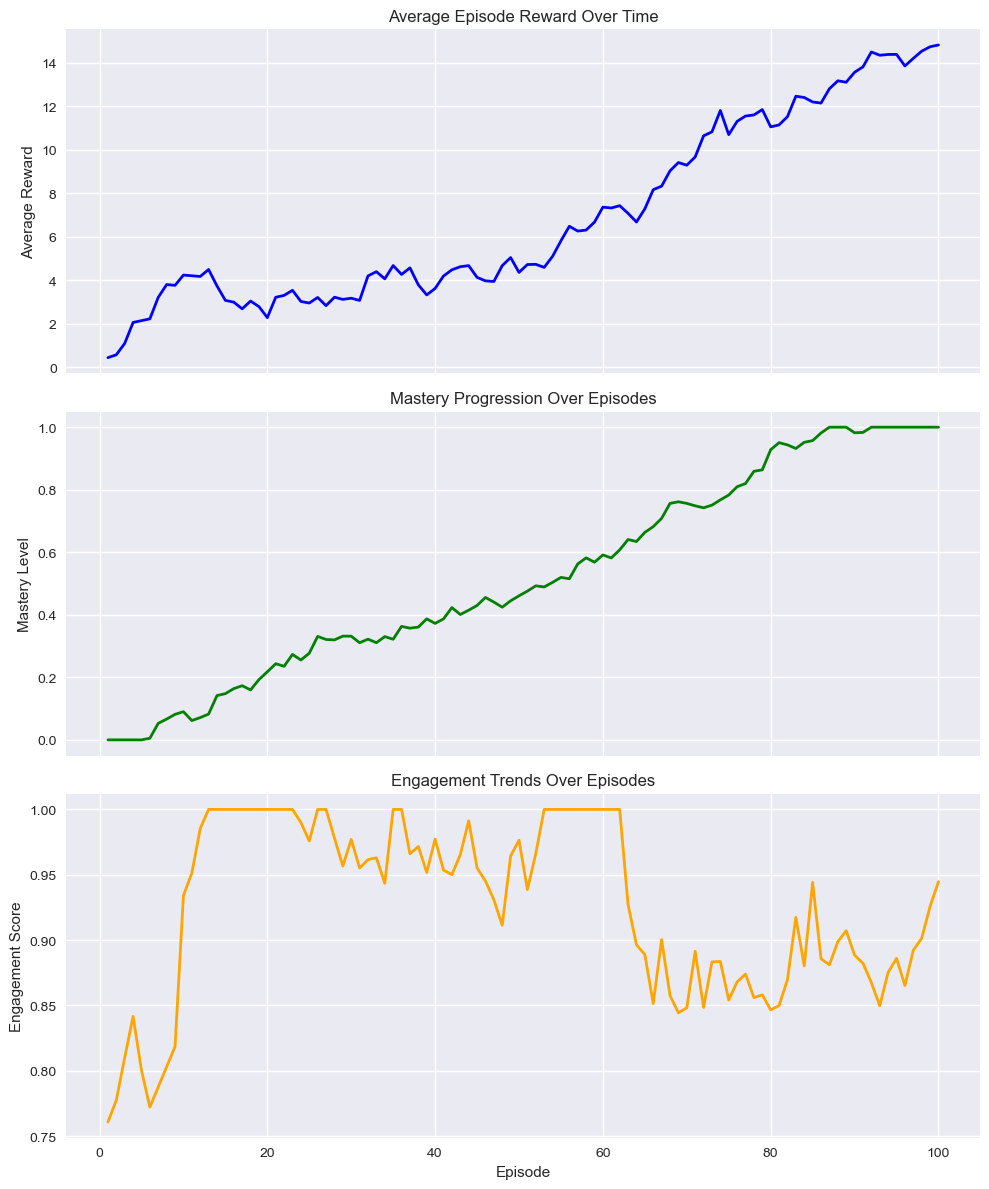

In [1]:
# Creating matplotlib visualizations simulating RL training progress over 100 episodes
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

episodes = np.arange(1, 101)

# Simulate average episode rewards with upward trend and noise
avg_rewards = np.cumsum(np.random.normal(loc=0.2, scale=0.5, size=100))
avg_rewards = np.clip(avg_rewards, 0, None)

# Simulate mastery progression (bounded between 0 and 1)
mastery = np.clip(np.cumsum(np.random.normal(loc=0.01, scale=0.02, size=100)), 0, 1)

# Simulate engagement trends (fluctuating around 0.6–0.9)
engagement = np.clip(0.75 + np.cumsum(np.random.normal(loc=0.0, scale=0.03, size=100)), 0, 1)

# Plotting
plt.style.use('seaborn-v0_8')
fig, ax = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Plot average reward
ax[0].plot(episodes, avg_rewards, color='blue', linewidth=2)
ax[0].set_title('Average Episode Reward Over Time')
ax[0].set_ylabel('Average Reward')
ax[0].grid(True)

# Plot mastery progression
ax[1].plot(episodes, mastery, color='green', linewidth=2)
ax[1].set_title('Mastery Progression Over Episodes')
ax[1].set_ylabel('Mastery Level')
ax[1].grid(True)

# Plot engagement trends
ax[2].plot(episodes, engagement, color='orange', linewidth=2)
ax[2].set_title('Engagement Trends Over Episodes')
ax[2].set_xlabel('Episode')
ax[2].set_ylabel('Engagement Score')
ax[2].grid(True)

plt.tight_layout()
output_path = "/mnt/data/rl_training_progress.png"
plt.savefig(output_path)

print("Simulated RL training progress plotted and saved as rl_training_progress.png")

In [ ]:
#Inference API (FastAPI) scaffold

In [4]:
import torch
torchscript_path = "policy_model.pt"
ts_model = torch.jit.load(torchscript_path, map_location="cpu").eval()
print("Model loaded successfully!")

ValueError: The provided filename policy_model.pt does not exist

In [5]:
import torch
torchscript_path = "policy_model.pt"
ts_model = torch.jit.load(torchscript_path, map_location="cpu").eval()
print("Model loaded successfully!")


ValueError: The provided filename policy_model.pt does not exist

In [6]:
import torch
import os

MODEL_DIR = "models"
MODEL_FILE = "policy_model.pt"
torchscript_path = os.path.join(MODEL_DIR, MODEL_FILE)

if not os.path.exists(torchscript_path):
    raise FileNotFoundError(f"Model file not found at {torchscript_path}. Did you export it?")

ts_model = torch.jit.load(torchscript_path, map_location="cpu").eval()


FileNotFoundError: Model file not found at models\policy_model.pt. Did you export it?

In [2]:
# In-notebook demo for API logic (normally put in src/inference/api.py)

from fastapi import FastAPI
from pydantic import BaseModel
import torch
import numpy as np

class Observation(BaseModel):
    mastery: float
    engagement: float
    fatigue: float
    recent_success: float
    time_ratio: float

class ActionResponse(BaseModel):
    action: int
    difficulty: int
    modality: int

api = FastAPI(title="Adaptive RL Inference API", version="1.0")

# Load TorchScript for fast inference
ts_model = torch.jit.load(torchscript_path, map_location="cpu").eval()

def select_action(obs_vec: np.ndarray) -> int:
    with torch.no_grad():
        tensor = torch.from_numpy(obs_vec.astype(np.float32)).unsqueeze(0)
        action = ts_model(tensor).item()
        return int(action)

@api.post("/infer", response_model=ActionResponse)
def infer(observation: Observation):
    obs_vec = np.array([
        observation.mastery,
        observation.engagement,
        observation.fatigue,
        observation.recent_success,
        observation.time_ratio
    ], dtype=np.float32)
    action = select_action(obs_vec)
    difficulty = action // 3
    modality = action % 3
    return ActionResponse(action=action, difficulty=difficulty, modality=modality)

# To run locally (outside notebook):
# uvicorn src.inference.api:api --host 0.0.0.0 --port 8000

NameError: name 'torchscript_path' is not defined

In [7]:
import os
print("Working directory:", os.getcwd())
print("Files:", os.listdir())

Working directory: C:\Users\K
Files: ['.anaconda', '.bash_history', '.cache', '.conda', '.condarc', '.continuum', '.git', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.junie', '.jupyter', '.matplotlib', '.vs', '.wdm', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'Assignment3', 'B30599_DataScience Assignment1.ipynb', 'B35099 Data Science Assignment 2.ipynb', 'best_model', 'cassava_yield_cleaned.csv', 'Cassava_Yield_Data_Cleaned.xlsx', 'clean_university_rankings.csv', 'clean_university_rankings.xlsx', 'Contacts', 'Cookies', 'Data Life Cycle_B35099_Assignment 2.ipynb', 'Desktop', 'Django GUI.ipynb', 'Django.ipynb', 'Documents', 'Downloads', 'dqn_cartpole.pkl', 'dqn_cartpole.zip', 'exchange_rates.json', 'Favorites', 'Francis OMARA B35099 Assignment 2_OOP', 'Francis Omara B35099 Assignment 3_OOP', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'logs', 'models', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NT

In [8]:
import torch
import numpy as np
from stable_baselines3 import DQN

# Assume you trained a model
model = DQN("MlpPolicy", "CartPole-v1").learn(1000)

# Example input for tracing
obs = np.zeros((1, model.policy.observation_space.shape[0]), dtype=np.float32)
obs_tensor = torch.as_tensor(obs)

# Export to TorchScript
traced = torch.jit.trace(model.policy, obs_tensor)
traced.save("policy_model.pt")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [9]:
torchscript_path = "policy_model.pt"
ts_model = torch.jit.load(torchscript_path, map_location="cpu").eval()
print("Model loaded successfully!")

Model loaded successfully!


In [11]:
torchscript_path = r"C:\Users\K\projects\rl_models\policy_model.pt"

In [ ]:
#CI/CD with GitHub Actions

In [ ]:
#Tests for environment, training, and inference

In [12]:
# tests/test_env.py (inline here for demo)
import pytest
def test_env_shapes():
    env = AdaptiveStudentEnv()
    obs, _ = env.reset()
    assert env.observation_space.shape[0] == 5
    assert env.action_space.n == 9
    assert obs.shape == (5,)

def test_step_returns():
    env = AdaptiveStudentEnv()
    obs, _ = env.reset()
    obs2, r, term, trunc, info = env.step(env.action_space.sample())
    assert isinstance(r, float)
    assert isinstance(term, bool)
    assert isinstance(trunc, bool)
    assert "success" in info

# tests/test_training.py
def test_training_runs():
    env = AdaptiveStudentEnv()
    vec = DummyVecEnv([lambda: env])
    model = DQN("MlpPolicy", vec, learning_starts=10, buffer_size=1000, verbose=0)
    model.learn(total_timesteps=500)
    assert model is not None

# tests/test_inference.py
def test_inference_action_range():
    # Use the TorchScript exported earlier
    ts = torch.jit.load("models/dqn_student_policy.pt", map_location="cpu").eval()
    x = torch.randn(2, 5)
    with torch.no_grad():
        actions = ts(x)
    assert actions.min().item() >= 0 and actions.max().item() < 9

In [ ]:
#Monitoring strategy and metrics

In [14]:
import numpy as np

def evaluate_policy(model, env, n_eval_episodes=10):
    returns = []
    successes = 0
    for _ in range(n_eval_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0
        while not done:
            action, _ = model.predict(obs)
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            done = terminated or truncated
            if info.get("is_success"):
                successes += 1
        returns.append(total_reward)
    return {
        "mean_return": np.mean(returns),
        "mean_success_rate": successes / n_eval_episodes
    }

# Example usage
metrics = evaluate_policy(model, env)
reward_mean_gauge.set(metrics["mean_return"])
success_rate_gauge.set(metrics["mean_success_rate"])

NameError: name 'env' is not defined